# Import and Preprocess NBA Dataset

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
file_path = "nbaplayersdraft.csv"

# Load the latest version
nba_player_data_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mattop/nba-draft-basketball-player-data-19892021",
  file_path,
  )

print("First 5 records:", nba_player_data_df.head())

# normalize names in order to merge
nba_player_data_df['player'] = nba_player_data_df['player'].str.lower()

display(nba_player_data_df.head())
print(f'Nba player data shape: {nba_player_data_df.shape}')

/tmp/ipykernel_28663/613913531.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  nba_player_data_df = kagglehub.load_dataset(


100%|██████████| 207k/207k [00:00<00:00, 319kB/s]


First 5 records:    id  year  rank  overall_pick team          player     college  \
0   1  1989     1             1  SAC  Pervis Ellison  Louisville   
1   2  1989     2             2  LAC     Danny Ferry        Duke   
2   3  1989     3             3  SAS    Sean Elliott     Arizona   
3   4  1989     4             4  MIA       Glen Rice    Michigan   
4   5  1989     5             5  CHH       J.R. Reid         UNC   

   years_active   games  minutes_played  ...  3_point_percentage  \
0          11.0   474.0         11593.0  ...               0.050   
1          13.0   917.0         18133.0  ...               0.393   
2          12.0   742.0         24502.0  ...               0.375   
3          15.0  1000.0         34985.0  ...               0.400   
4          11.0   672.0         15370.0  ...               0.135   

   free_throw_percentage  average_minutes_played  points_per_game  \
0                  0.689                    24.5              9.5   
1                  0.840   

,id,year,rank,overall_pick,team,player,college,years_active,games,minutes_played,...,3_point_percentage,free_throw_percentage,average_minutes_played,points_per_game,average_total_rebounds,average_assists,win_shares,win_shares_per_48_minutes,box_plus_minus,value_over_replacement
0,1,1989,1,1,SAC,pervis ellison,Louisville,11.0,474.0,11593.0,...,0.050,0.689,24.5,9.5,6.7,1.5,21.8,0.090,-0.5,4.4
1,2,1989,2,2,LAC,danny ferry,Duke,13.0,917.0,18133.0,...,0.393,0.840,19.8,7.0,2.8,1.3,34.8,0.092,-0.9,4.9
2,3,1989,3,3,SAS,sean elliott,Arizona,12.0,742.0,24502.0,...,0.375,0.799,33.0,14.2,4.3,2.6,55.7,0.109,0.2,13.5
3,4,1989,4,4,MIA,glen rice,Michigan,15.0,1000.0,34985.0,...,0.400,0.846,35.0,18.3,4.4,2.1,88.7,0.122,0.8,24.9
4,5,1989,5,5,CHH,j.r. reid,UNC,11.0,672.0,15370.0,...,0.135,0.716,22.9,8.5,5.0,1.0,22.5,0.070,-2.9,-3.7


Nba player data shape: (1922, 24)


# Import and Preprocess NCAA Dataset

In [2]:
file_path_2 = "CollegeBasketballPlayers2009-2021.csv"

ncaa_stats_df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "adityak2003/college-basketball-players-20092021",
  file_path_2,
  )

print("First 5 records:", ncaa_stats_df.head())
ncaa_stats_df['player_name'] = ncaa_stats_df['player_name'].str.lower()

# Prepend 'ncaa_' to all columns
ncaa_stats_df = ncaa_stats_df.rename(columns={col: f'ncaa_{col}' for col in ncaa_stats_df.columns if col != 'player_name' and not col.startswith('ncaa_')})

# filter out non-numerical columns
cols_to_drop = [
    'ncaa_rimmade', 'ncaa_rimmade+rimmiss', 'ncaa_midmade', 'ncaa_midmade+midmiss',
    'ncaa_rimmade/(rimmade+rimmiss)', 'ncaa_midmade/(midmade+midmiss)',
    'ncaa_dunksmade', 'ncaa_dunksmiss+dunksmade', 'ncaa_dunksmade/(dunksmade+dunksmiss)'
    ,'ncaa_Unnamed: 64', 'ncaa_type', 'ncaa_yr', 'ncaa_ht', 'ncaa_num'
]


existing_cols_to_drop = [col for col in cols_to_drop if col in ncaa_stats_df.columns]

ncaa_stats_df = ncaa_stats_df.drop(columns=existing_cols_to_drop)

first_cols = ['ncaa_team', 'ncaa_conf']

# create aggregation rules to avoid preprocessing errors
agg_rules = {col: 'mean' for col in ncaa_stats_df.columns if col not in (['player_name'] + first_cols)}

for col in first_cols:
    agg_rules[col] = 'first'

ncaa_stats_df = ncaa_stats_df.groupby('player_name', as_index=False).agg(agg_rules)

display(ncaa_stats_df.head())
print(f'Ncaa Stats Shape: {ncaa_stats_df.shape}')


/tmp/ipykernel_28663/2553735687.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  ncaa_stats_df = kagglehub.load_dataset(


100%|██████████| 8.97M/8.97M [00:01<00:00, 7.23MB/s]

Extracting zip of CollegeBasketballPlayers2009-2021.csv...



/usr/local/lib/python3.12/dist-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


First 5 records:        player_name           team conf  GP  Min_per   Ortg   usg   eFG  \
0    DeAndrae Ross  South Alabama   SB  26     29.5   97.3  16.6  42.5   
1    Pooh Williams       Utah St.  WAC  34     60.9  108.3  14.9  52.4   
2    Jesus Verdejo  South Florida   BE  27     72.0   96.2  21.8  45.7   
3  Mike Hornbuckle     Pepperdine  WCC  30     44.5   97.7  16.0  53.6   
4    Anthony Brown        Pacific   BW  33     56.2   96.5  22.0  52.8   

   TS_per  ORB_per  ...     dgbpm    oreb    dreb    treb     ast     stl  \
0   44.43      1.6  ... -1.941150  0.1923  0.6154  0.8077  1.1923  0.3462   
1   54.48      3.8  ... -0.247934  0.6765  1.2647  1.9412  1.8235  0.4118   
2   47.98      2.1  ... -0.883163  0.6296  2.3333  2.9630  1.9630  0.4815   
3   53.69      4.1  ... -0.393459  0.7000  1.4333  2.1333  1.1000  0.5667   
4   54.31      8.3  ... -0.668318  1.4242  3.3030  4.7273  0.8485  0.4545   

      blk      pts  Unnamed: 64  Unnamed: 65  
0  0.0385   3.8846          

,player_name,ncaa_GP,ncaa_Min_per,ncaa_Ortg,ncaa_usg,ncaa_eFG,ncaa_TS_per,ncaa_ORB_per,ncaa_DRB_per,ncaa_AST_per,...,ncaa_oreb,ncaa_dreb,ncaa_treb,ncaa_ast,ncaa_stl,ncaa_blk,ncaa_pts,ncaa_Unnamed: 65,ncaa_team,ncaa_conf
0,a'torey everett,23.00,19.00,88.000,15.70,40.500,50.0800,1.600,8.100,14.500,...,0.125000,0.750000,0.875000,0.708300,0.083300,0.041700,2.416700,1.878270,Tennessee St.,OVC
1,a'torri shine,27.00,79.30,94.100,23.10,45.400,49.9850,4.000,10.100,8.200,...,1.132150,2.699250,3.831400,0.950850,0.670500,0.215850,13.027450,7.937060,Grambling St.,SWAC
2,a'uston calhoun,23.50,54.95,99.575,24.85,47.650,50.4900,6.225,12.675,4.075,...,1.568950,3.055575,4.624525,0.501925,0.400150,0.393150,11.303550,10.966038,Bowling Green,MAC
3,a.c. reid,23.75,39.95,69.025,16.70,34.475,35.7225,0.625,9.725,11.900,...,0.094825,1.534850,1.629675,1.127825,0.447025,0.103825,4.362075,13.781475,Liberty,BSth
4,a.d. vassallo,34.00,89.80,111.800,25.00,53.000,56.5000,4.400,14.700,16.700,...,1.382400,4.823500,6.205900,2.588200,0.823500,0.852900,19.058800,10.674900,Virginia Tech,ACC


Ncaa Stats Shape: (25582, 52)


# Merge NBA and NCAA datasets

In [3]:
import pandas as pd

# merge the nbaa and nca datasets
merged_df = pd.merge(
    nba_player_data_df,
    ncaa_stats_df,
    left_on='player',
    right_on='player_name',
    how='inner'
)

display(merged_df.head())
print(f'Merged shape (Inner Join): {merged_df.shape}')

,id,year,rank,overall_pick,team,player,college,years_active,games,minutes_played,...,ncaa_oreb,ncaa_dreb,ncaa_treb,ncaa_ast,ncaa_stl,ncaa_blk,ncaa_pts,ncaa_Unnamed: 65,ncaa_team,ncaa_conf
0,4,1989,4,4,MIA,glen rice,Michigan,15.0,1000.0,34985.0,...,1.696033,3.4121,5.1081,2.150567,1.282200,0.571600,10.333733,7.749063,Georgia Tech,ACC
1,13,1989,13,13,BOS,michael smith,BYU,3.0,141.0,1328.0,...,0.000000,0.0000,0.0000,0.125000,0.000000,0.000000,0.375000,0.000000,Longwood,BSth
2,31,1989,31,31,LAC,jeff martin,Murray State,2.0,143.0,2685.0,...,0.000000,0.1500,0.1500,0.133350,0.050000,0.000000,0.850000,13.935100,Murray St.,OVC
3,51,1989,51,51,PHO,mike morrison,Loyola (MD),1.0,36.0,153.0,...,1.161300,1.3226,2.4839,0.290300,0.129000,0.677400,3.967700,0.000000,George Mason,CAA
4,73,1990,19,19,BOS,dee brown,Jacksonville University,12.0,608.0,16843.0,...,0.368100,1.7053,2.0734,1.569250,0.708025,0.050975,8.415150,6.272647,Bowling Green,MAC


Merged shape (Inner Join): (674, 76)


# Split Data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Split
merged_df = merged_df.dropna()
training_df, testing_df = train_test_split(merged_df, test_size=0.2, random_state=42)

training_y = training_df["value_over_replacement"]
training_x = training_df.drop(columns=["value_over_replacement"]).select_dtypes(include=["number"])
testing_y  = testing_df["value_over_replacement"]
testing_x  = testing_df.drop(columns=["value_over_replacement"]).select_dtypes(include=["number"])

# Scale
scaler_x = StandardScaler()
scaled_training_x = scaler_x.fit_transform(training_x)
scaled_testing_x  = scaler_x.transform(testing_x)

# PCA
pca = PCA(n_components=20, random_state=42)
training_x_pca = pca.fit_transform(scaled_training_x)
testing_x_pca  = pca.transform(scaled_testing_x)

# Binary target
threshold = training_y.median()
training_y_binary = (training_y > threshold).astype(float)
testing_y_binary  = (testing_y > threshold).astype(float)

# Logisitc Regression

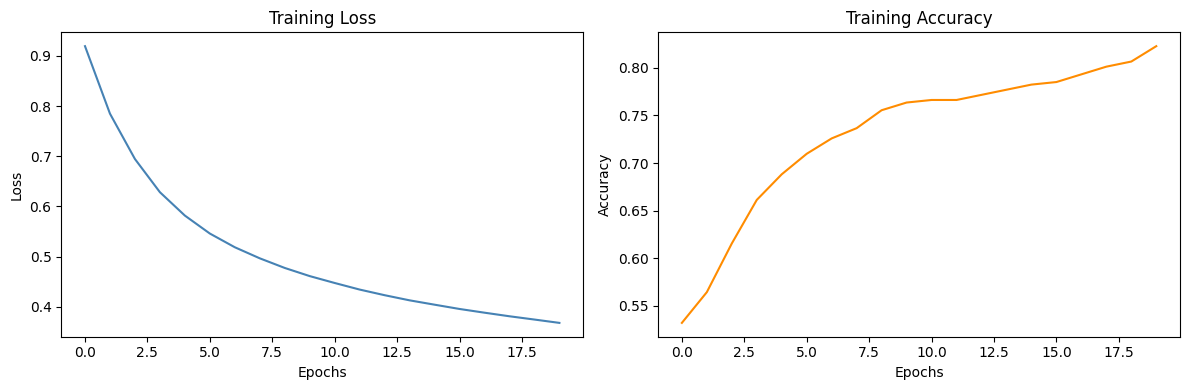

In [ ]:
log_reg = Sequential([
    Input(shape=(20,)),
    Dense(1, activation='sigmoid')
])
log_reg.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
history = log_reg.fit(training_x_pca, training_y_binary, epochs=20, verbose=0)

# Plot 1 — Training loss curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='steelblue')
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Plot 2 — Training accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], color='darkorange')
plt.title("Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

## Model Evaluation on Testing Data

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Test Accuracy: 0.8298
              precision    recall  f1-score   support

 Not Success       0.77      0.91      0.84        45
     Success       0.90      0.76      0.82        49

    accuracy                           0.83        94
   macro avg       0.84      0.83      0.83        94
weighted avg       0.84      0.83      0.83        94



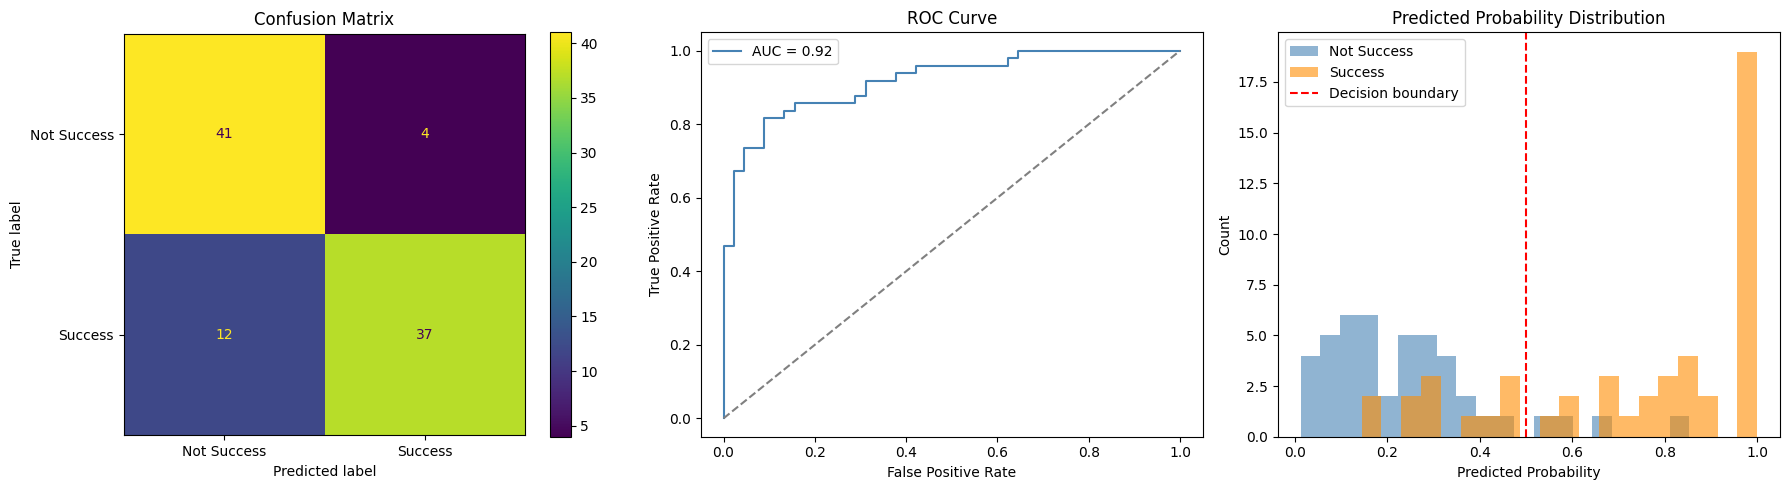

In [ ]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc)

y_pred_probabilities = log_reg.predict(testing_x_pca).flatten()
y_pred_classes       = (y_pred_probabilities > 0.5).astype(int)

print(f"Test Accuracy: {accuracy_score(testing_y_binary, y_pred_classes):.4f}")
print(classification_report(testing_y_binary, y_pred_classes,
                            target_names=["Not Success", "Success"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 3 — Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(testing_y_binary, y_pred_classes),
    display_labels=["Not Success", "Success"]
).plot(ax=axes[0])
axes[0].set_title("Confusion Matrix")

# Plot 4 — ROC curve
fpr, tpr, _ = roc_curve(testing_y_binary, y_pred_probabilities)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='grey', linestyle='--')
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

# Plot 5 — Predicted probability distribution
axes[2].hist(y_pred_probabilities[testing_y_binary == 0], bins=20,
             alpha=0.6, color='steelblue', label='Not Success')
axes[2].hist(y_pred_probabilities[testing_y_binary == 1], bins=20,
             alpha=0.6, color='darkorange', label='Success')
axes[2].axvline(0.5, color='red', linestyle='--', label='Decision boundary')
axes[2].set_title("Predicted Probability Distribution")
axes[2].set_xlabel("Predicted Probability")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

# Feature Selection and Data Preparation

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models

targets = ['value_over_replacement']

ncaa_features = [col for col in merged_df.columns if col.startswith('ncaa_')]
features = merged_df[ncaa_features].select_dtypes(include=[np.number]).columns.tolist()
features = [f for f in features if f not in ['ncaa_pid', 'ncaa_year']]

# filter out rows where VORP is NaN
data = merged_df.dropna(subset=targets)


X = data[features].fillna(data[features].mean())
y = data[targets]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Selected Features: {len(features)}')
print(f'Targets: {targets}')
print(f'Training features shape: {X_train_scaled.shape}')
print(f'Training labels shape: {y_train.shape}')

Selected Features: 47
Targets: ['value_over_replacement']
Training features shape: (502, 47)
Training labels shape: (502, 1)


# Simple Feed Forward Neural Network Model

In [5]:
from sklearn.metrics import r2_score

model = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_scaled, y_train,
    epochs=250,
    validation_split=0.2,
    verbose=0
)

loss, mae = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_nn = model.predict(X_test_scaled, verbose=0)
r2_nn = r2_score(y_test, y_pred_nn)

print(f'Original Model (MSE) Test MAE: {mae:.4f}')
print(f'Original Model (MSE) Test R2 Score: {r2_nn:.4f}')

Original Model (MSE) Test MAE: 4.9724
Original Model (MSE) Test R2 Score: 0.1658


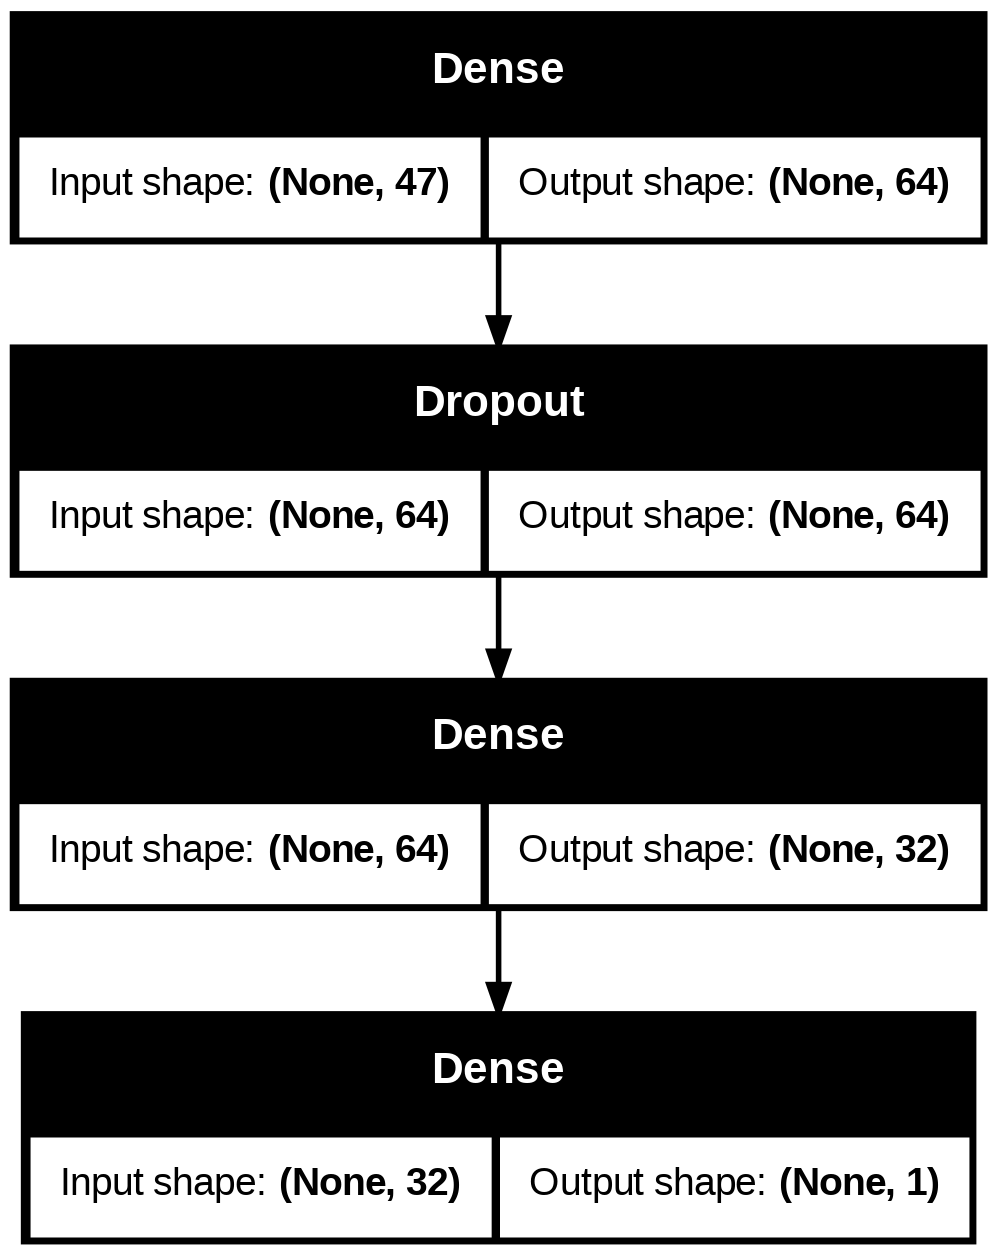

In [6]:
tf.keras.utils.plot_model(model, show_shapes=True)

### Neural Network Loss Visualized

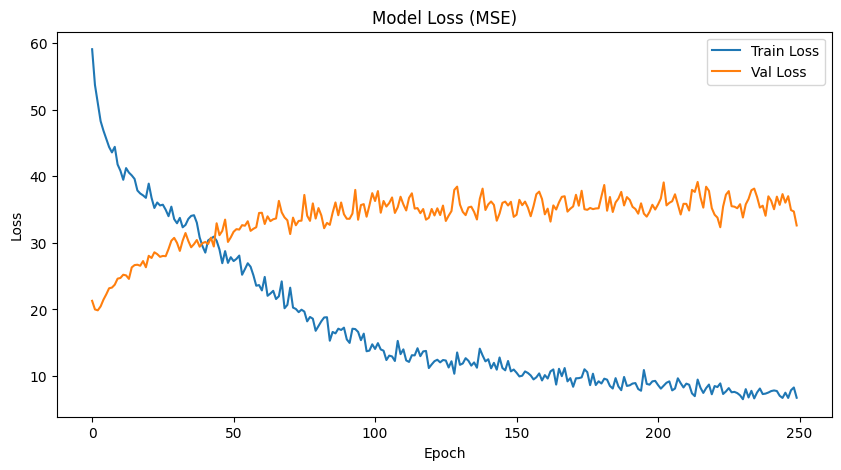

In [7]:
import matplotlib.pyplot as plt

# Plot neural network training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### XGBoost Regression Model

In [8]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, r2_score

y_train_vor = y_train['value_over_replacement']
y_test_vor = y_test['value_over_replacement']

xgb_model = xgb.XGBRegressor(
    objective='reg:pseudohubererror',
    n_estimators=1000,
    learning_rate=0.001,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

xgb_model.fit(
    X_train, y_train_vor,
    eval_set=[(X_test, y_test_vor)],
    verbose=False
)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
mae_xgb = mean_absolute_error(y_test_vor, y_pred)
r2_xgb = r2_score(y_test_vor, y_pred)

print(f'XGBoost (Pseudo-Huber) Test MAE: {mae_xgb:.4f}')
print(f'XGBoost (Pseudo-Huber) Test R2 Score: {r2_xgb:.4f}')

XGBoost (Pseudo-Huber) Test MAE: 4.1088
XGBoost (Pseudo-Huber) Test R2 Score: 0.0094


### Plot most influential features in XGBoost

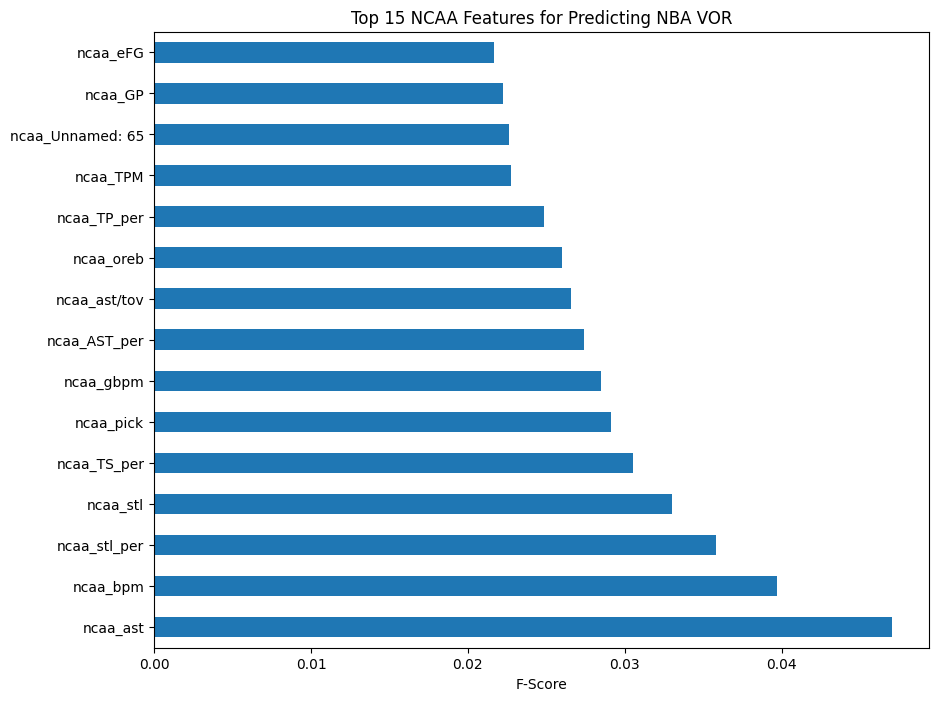

In [9]:
plt.figure(figsize=(10, 8))
feat_importances = pd.Series(xgb_model.feature_importances_, index=features)
feat_importances.nlargest(15).plot(kind='barh')
plt.title('Top 15 NCAA Features for Predicting NBA VOR')
plt.xlabel('F-Score')
plt.show()

# Discussion

### explore using different loss functions in XGBoost

In [10]:
import xgboost as xgb
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

# Define the objectives to compare
objectives = {
    'MSE (Squared Error)': 'reg:squarederror',
    'MAE (Absolute Error)': 'reg:absoluteerror',
    'Pseudo-Huber Loss': 'reg:pseudohubererror'
}

results = []

for name, obj in objectives.items():
    # Initialize model with specific objective
    model = xgb.XGBRegressor(
        objective=obj,
        n_estimators=1000,
        learning_rate=0.001,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train_vor, eval_set=[(X_test, y_test_vor)], verbose=False)

    # Predict and Evaluate
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test_vor, preds)
    r2 = r2_score(y_test_vor, preds)

    results.append({
        'Objective': name,
        'Test MAE': round(mae, 4),
        'Test R2': round(r2, 4)
    })

# Display comparison table
comparison_df = pd.DataFrame(results)
display(comparison_df)

,Objective,Test MAE,Test R2
0,MSE (Squared Error),4.9626,-0.0051
1,MAE (Absolute Error),4.1294,-0.0338
2,Pseudo-Huber Loss,4.1088,0.0094


### Explore using different loss functions in Neural Network

In [11]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score

nn_losses = ['mse', 'mae', 'huber']
nn_results = []
histories = {}

for loss_name in nn_losses:
    model_variant = models.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])

    model_variant.compile(optimizer='adam', loss=loss_name, metrics=['mae'])

    histories[loss_name] = model_variant.fit(
        X_train_scaled, y_train,
        epochs=250,
        validation_split=0.2,
        verbose=0
    )

    preds = model_variant.predict(X_test_scaled, verbose=0)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    nn_results.append({
        'Loss Function': loss_name.upper(),
        'Test MAE': round(float(mae), 4),
        'Test R2': round(float(r2), 4)
    })


nn_comparison_df = pd.DataFrame(nn_results)
display(nn_comparison_df)

,Loss Function,Test MAE,Test R2
0,MSE,5.1644,0.1259
1,MAE,5.0710,0.1191
2,HUBER,5.0511,0.1209


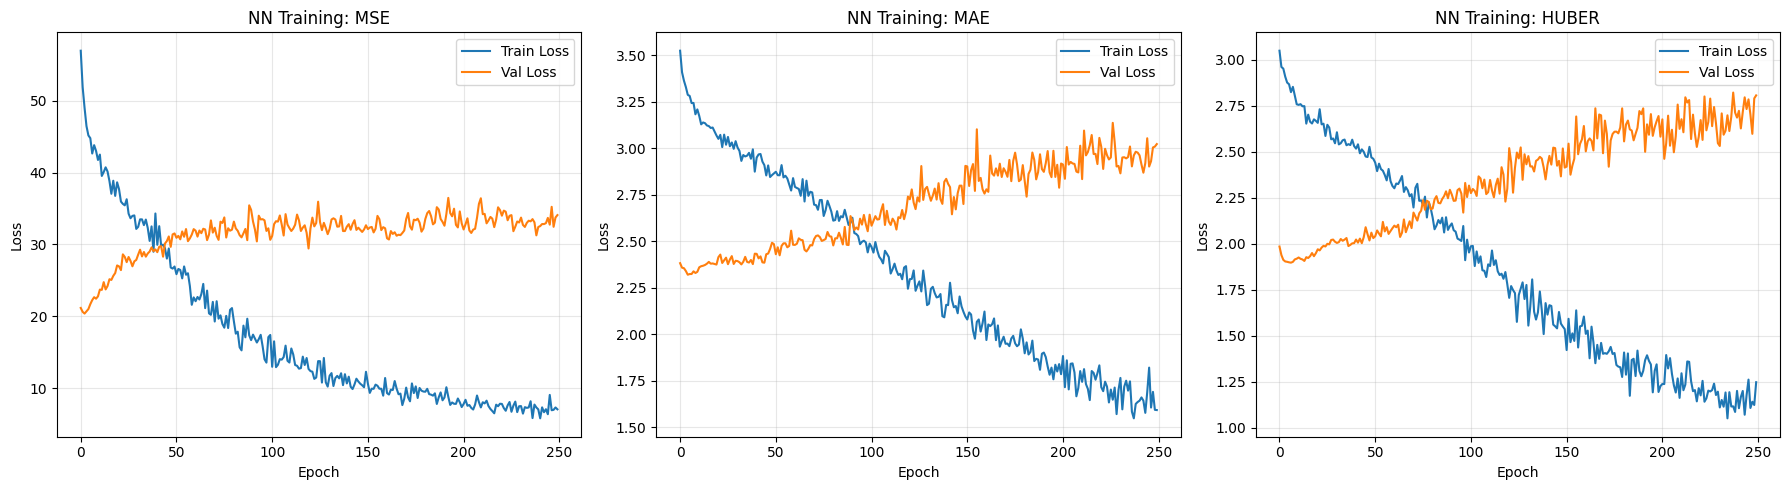

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, loss_name in enumerate(nn_losses):
    axes[i].plot(histories[loss_name].history['loss'], label='Train Loss')
    axes[i].plot(histories[loss_name].history['val_loss'], label='Val Loss')
    axes[i].set_title(f'NN Training: {loss_name.upper()}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()